1. Analisis Exploratorio de Datos

In [273]:
# Imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")

In [274]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [275]:
# Loading Dataset and reading sample

df = pd.read_csv("../data/raw/casas_dev.csv")
df.sample(10)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
814,9135.610193,depto,62.824783,59.861460,m2,7,NaN,False,-34.773783,-58.202253,14.852188
1309,110965.210846,depto,681.412050,673.051028,sqft,5,NaN,False,40.731345,-74.030089,1.806286
53,137613.423879,depto,701.519858,689.296424,sqft,7,NaN,False,40.706608,-73.972500,1.777350
356,98088.955859,depto,664.327221,660.293424,sqft,3,NaN,False,40.692518,-73.998843,NaN
17,31160.129665,casa,229.093308,94.814414,m2,8,3.0,True,-34.684875,-58.282674,37.911016
146,17433.457597,casa,194.949044,145.770427,m2,7,3.0,False,-34.746788,-58.203441,5.109342
537,127675.097105,depto,747.398725,726.028706,sqft,8,NaN,False,40.700440,-73.917817,6.083798
184,127009.871364,depto,693.151942,684.696063,sqft,5,NaN,False,40.696111,-73.967488,4.027774
1260,37256.957916,casa,242.477434,134.342263,m2,10,3.0,True,-34.787223,-58.160211,NaN
194,245874.339629,depto,640.880465,611.571388,sqft,4,NaN,False,40.811437,-74.008156,3.081278


In [276]:
# Columns overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   precio            1545 non-null   float64
 1   tipo              1600 non-null   object 
 2   Área              1600 non-null   float64
 3   metros_cubiertos  1600 non-null   float64
 4   unidades          1600 non-null   object 
 5   ambientes         1600 non-null   int64  
 6   pisos             748 non-null    float64
 7   pileta            1600 non-null   bool   
 8   lat               1600 non-null   float64
 9   lon               1600 non-null   float64
 10  edad              1451 non-null   float64
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 126.7+ KB


In [277]:
# Uniqueness

df.nunique()

precio              1489
tipo                   3
Área                1600
metros_cubiertos    1600
unidades               2
ambientes             10
pisos                  3
pileta                 2
lat                 1600
lon                 1600
edad                1433
dtype: int64

In [278]:
# General statistics

df.describe()

,precio,Área,metros_cubiertos,ambientes,pisos,lat,lon,edad
count,1545.000000,1600.000000,1600.000000,1600.000000,748.000000,1600.000000,1600.000000,1451.000000
mean,93343.692526,441.793691,389.079682,6.915000,2.617647,-2.060019,-65.065245,22.921058
std,96555.245985,312.059318,316.426294,2.491316,0.671316,37.430008,7.802823,21.160659
min,0.000000,54.214835,52.612659,1.000000,1.000000,-34.861494,-74.058871,1.000000
25%,15425.306495,213.297952,114.295562,5.000000,2.000000,-34.782040,-73.987461,7.004693
50%,43042.341770,251.370981,166.433788,7.000000,3.000000,-34.704058,-58.288150,13.101679
75%,169055.639631,734.053341,712.503363,10.000000,3.000000,40.730409,-58.244678,37.929431
max,769962.673560,2475.718589,1553.965444,10.000000,3.000000,40.851404,-58.159866,96.440005


In [279]:
# Missing data count

df.isnull().sum()

precio               55
tipo                  0
Área                  0
metros_cubiertos      0
unidades              0
ambientes             0
pisos               852
pileta                0
lat                   0
lon                   0
edad                149
dtype: int64

In [280]:
# Missing data proportions

missing_precio = (df["precio"].isnull().sum() / len(df)) * 100
print(f"precio: ~{missing_precio:.2f}%")

missing_edad = (df["edad"].isnull().sum() / len(df)) * 100
print(f"edad: ~{missing_edad:.2f}%")

missing_pisos = (df["pisos"].isnull().sum() / len(df)) * 100
print(f"pisos: ~{missing_pisos:.2f}%")


precio: ~3.44%
edad: ~9.31%
pisos: ~53.25%


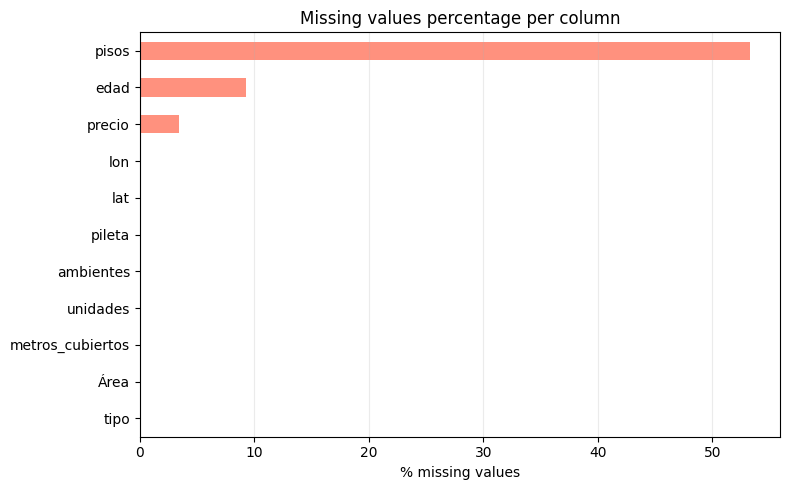

In [281]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=True)
missing_pct.plot(kind='barh', color='tomato', alpha=0.7, ax=ax)
ax.set_xlabel('% missing values')
ax.set_title('Missing values percentage per column')
ax.grid(alpha=0.25, axis='x')
plt.tight_layout()
plt.show()

PISOS

In [282]:
# Missing data in feature 'pisos'

print(df['pisos'].isna().groupby(df['tipo']).sum()) 
# no es que falta el value, sino que ES NO APLICABLE para departamentos el feature pisos!!!


tipo
casa       0
depto    852
ph         0
Name: pisos, dtype: int64


In [283]:
df[df['pisos'].isna()]

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
0,159001.587058,depto,721.976728,703.066245,sqft,5,NaN,False,40.738155,-73.992277,NaN
2,NaN,depto,73.856399,72.887849,m2,4,NaN,False,-34.704461,-58.256815,2.085965
3,135972.861876,depto,776.709623,747.693158,sqft,5,NaN,False,40.847320,-74.011712,13.835526
7,179452.480343,depto,851.461518,830.991007,sqft,2,NaN,False,40.817814,-74.035487,6.673449
9,221054.994134,depto,830.968041,821.480555,sqft,5,NaN,False,40.726963,-73.939846,14.963269
...,...,...,...,...,...,...,...,...,...,...,...
1593,162749.789067,depto,852.771314,814.847686,sqft,7,NaN,False,40.711017,-73.928098,10.930534
1594,216319.401607,depto,742.705566,713.828490,sqft,9,NaN,False,40.730332,-73.949326,5.025834
1595,161092.730185,depto,780.737575,777.125532,sqft,5,NaN,False,40.777561,-73.928190,1.603134
1597,0.000000,depto,800.370634,761.852744,sqft,7,NaN,False,40.734165,-73.978716,13.293942


LAT & LON

PRECIO

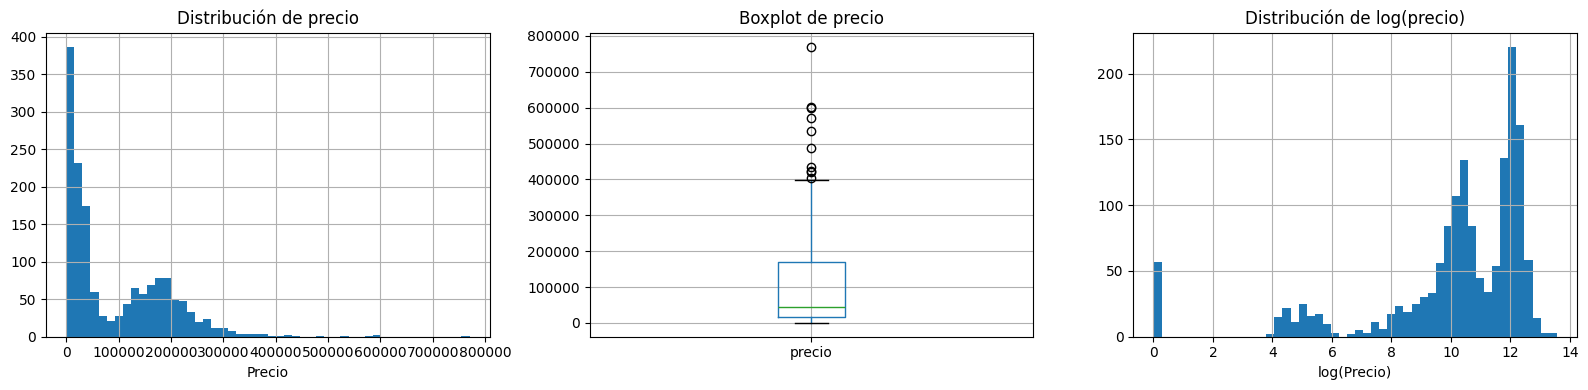

count      1545.000000
mean      93343.692526
std       96555.245985
min           0.000000
25%       15425.306495
50%       43042.341770
75%      169055.639631
max      769962.673560
Name: precio, dtype: float64

Skewness: 1.254


In [284]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del precio
df['precio'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribución de precio')
axes[0].set_xlabel('Precio')

# Boxplot para ver outliers
df.boxplot(column='precio', ax=axes[1])
axes[1].set_title('Boxplot de precio')

# Distribución del log del precio
np.log1p(df['precio']).hist(bins=50, ax=axes[2])
axes[2].set_title('Distribución de log(precio)')
axes[2].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

print(df['precio'].describe())
print(f"\nSkewness: {df['precio'].skew():.3f}")

In [285]:
# Investigá esto:
print(df[df['precio'] < 100][['precio', 'unidades', 'tipo', 'Área']].head(20))

        precio unidades   tipo        Área
6    84.244291       m2     ph  115.819630
15   94.822001       m2  depto   77.623869
21   80.746216       m2  depto   74.347339
38    0.000000       m2   casa  228.691782
43    0.000000       m2   casa  232.323738
71    0.000000     sqft  depto  826.326231
102   0.000000       m2  depto   68.203506
128  96.149413       m2  depto   70.416935
142   0.000000     sqft  depto  702.900945
156  93.759837       m2  depto   90.397938
172  76.481611       m2  depto   77.646008
180   0.000000       m2   casa  190.693267
198   0.000000       m2   casa  250.811501
199  62.677931       m2  depto   77.031365
213  86.464713       m2  depto   82.000707
236   0.000000       m2     ph  134.219848
285  63.360328       m2  depto   66.521066
306   0.000000       m2   casa  205.362880
307   0.000000       m2   casa  260.131058
313  93.285333       m2     ph  111.761338


In [286]:
print(df[(df['precio'] < 100000) & (df['precio'] > 70000)][['precio', 'unidades', 'tipo', 'Área']].head(20))

           precio unidades   tipo        Área
91   99588.776406     sqft  depto  683.320711
140  97739.536265     sqft  depto  759.309907
187  93252.453388       m2   casa  251.240126
271  73056.048325     sqft  depto  705.550414
339  77052.815041       m2   casa  201.376155
356  98088.955859     sqft  depto  664.327221
374  87909.857836       m2   casa  255.041945
401  92206.440104     sqft  depto  816.985559
430  98378.506404     sqft  depto  785.068081
440  82019.247854       m2   casa  219.148678
455  87903.055361       m2   casa  241.225868
470  90851.496089       m2   casa  245.360778
488  72811.487850     sqft  depto  822.702723
552  99526.079362     sqft  depto  708.687659
607  91420.590863     sqft  depto  840.058749
646  80076.837989       m2   casa  257.215489
653  80591.309604     sqft  depto  759.632140
678  80980.916391     sqft  depto  762.122211
705  76836.108191       m2   casa  227.126450
738  92922.351730     sqft  depto  810.547605


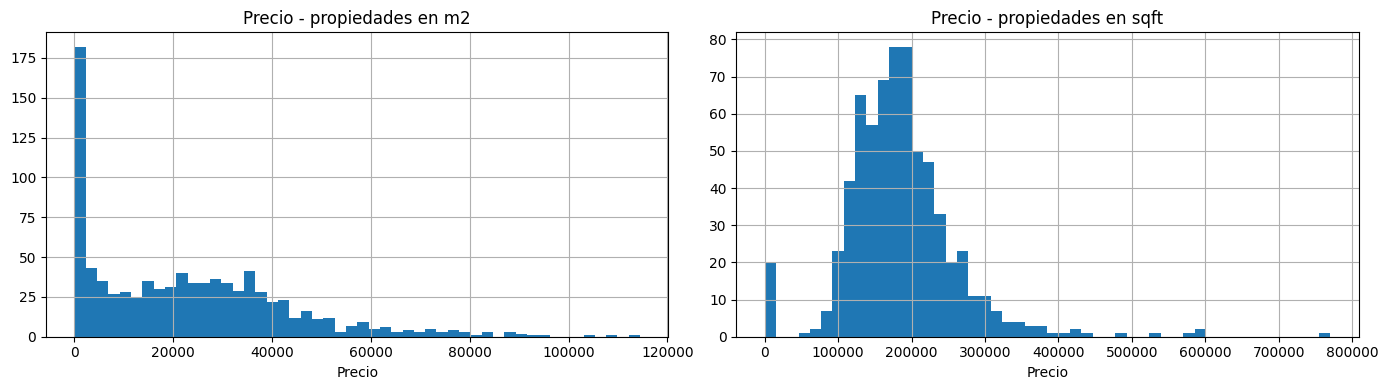

Estadísticas precio en m2:
count       876.000000
mean      23021.185463
std       20631.981961
min           0.000000
25%        4130.007417
50%       20865.868299
75%       35116.067489
max      114468.672042
Name: precio, dtype: float64

Estadísticas precio en sqft:
count       669.000000
mean     185425.181596
std       77552.550549
min           0.000000
25%      139937.555600
50%      179347.253703
75%      219477.145996
max      769962.673560
Name: precio, dtype: float64


In [287]:
# Distribucion de precio separado por unidades
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['unidades']=='m2']['precio'].hist(bins=50, ax=axes[0])
axes[0].set_title('Precio - propiedades en m2')
axes[0].set_xlabel('Precio')

df[df['unidades']=='sqft']['precio'].hist(bins=50, ax=axes[1])
axes[1].set_title('Precio - propiedades en sqft')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

print("Estadísticas precio en m2:")
print(df[df['unidades']=='m2']['precio'].describe())
print("\nEstadísticas precio en sqft:")
print(df[df['unidades']=='sqft']['precio'].describe())

In [288]:
# Investigá la composicion de ese pico
print(df[(df['unidades']=='m2') & (df['precio'] < 1000)][['precio','tipo','Área','metros_cubiertos', 'lat']].head(20))
print(f"\nCuántos registros: {len(df[(df['unidades']=='m2') & (df['precio'] < 1000)])}")

         precio   tipo        Área  metros_cubiertos        lat
6     84.244291     ph  115.819630         89.400354 -34.787597
15    94.822001  depto   77.623869         74.044851 -34.806706
16   175.665971     ph  137.816833        116.687955 -34.746740
20   204.631489   casa  219.806668        109.071154 -34.670645
21    80.746216  depto   74.347339         72.731793 -34.814687
38     0.000000   casa  228.691782        144.378650 -34.717182
43     0.000000   casa  232.323738        123.652062 -34.715316
60   147.258399  depto   85.483453         83.647982 -34.812448
66   274.461516   casa  224.485049        116.102638 -34.844478
79   133.177442     ph  123.232857        105.064330 -34.670138
98   251.874318   casa  203.856713        118.925391 -34.818774
102    0.000000  depto   68.203506         65.069758 -34.784240
109  120.632800     ph  123.447567         89.145263 -34.846778
128   96.149413  depto   70.416935         68.763169 -34.812351
131  280.966993   casa  258.995517      

In [289]:
# Cuántos son = 0 vs > 0 dentro de ese grupo
mask_m2_bajo = (df['unidades']=='m2') & (df['precio'] < 1000)
print(df[mask_m2_bajo]['precio'].value_counts().head(10))
print(f"\nIguales a 0: {(df[mask_m2_bajo]['precio'] == 0).sum()}")
print(f"Mayores a 0: {(df[mask_m2_bajo]['precio'] > 0).sum()}")

precio
0.000000      37
84.244291      1
158.024783     1
248.572900     1
138.944830     1
106.354645     1
107.787911     1
98.878576      1
90.161279      1
367.381505     1
Name: count, dtype: int64

Iguales a 0: 37
Mayores a 0: 125


In [290]:
print(f"Zeros en sqft: {((df['unidades']=='sqft') & (df['precio']==0)).sum()}")
print(f"Precios bajos en sqft (< 1000): {((df['unidades']=='sqft') & (df['precio']< 1000) & (df['precio']>0)).sum()}")

Zeros en sqft: 20
Precios bajos en sqft (< 1000): 0


count    1451.000000
mean       22.921058
std        21.160659
min         1.000000
25%         7.004693
50%        13.101679
75%        37.929431
max        96.440005
Name: edad, dtype: float64

Skewness de edad: 1.066


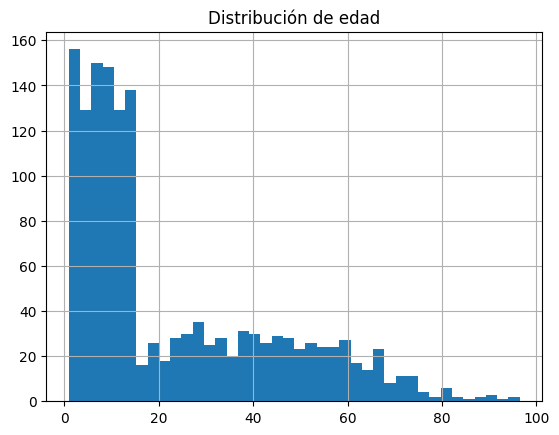

In [291]:
# Antes de decidir, mirá esto:
print(df['edad'].describe())
print(f"\nSkewness de edad: {df['edad'].skew():.3f}")
df['edad'].hist(bins=40)
plt.title('Distribución de edad')
plt.show()

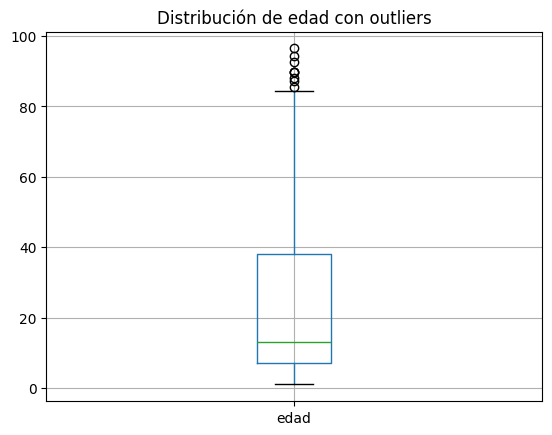

Propiedades con edad > 60 años: 108
Propiedades con edad > 80 años: 15


In [292]:
# Una última cosa antes de cerrar el diagnóstico:
df.boxplot(column='edad')
plt.title('Distribución de edad con outliers')
plt.show()

print(f"Propiedades con edad > 60 años: {(df['edad'] > 60).sum()}")
print(f"Propiedades con edad > 80 años: {(df['edad'] > 80).sum()}")

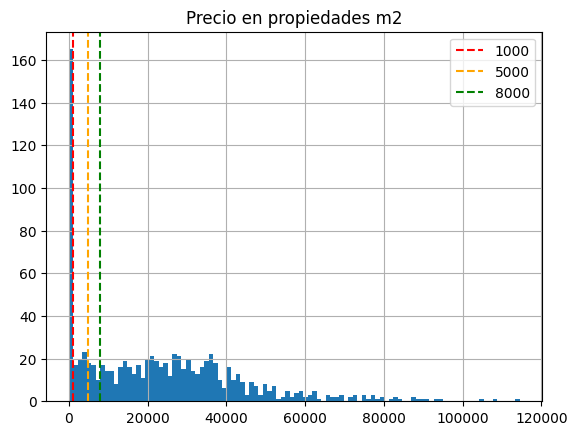

Precio entre 0 y 1000: 125 registros
Precio entre 0 y 2000: 143 registros
Precio entre 0 y 5000: 197 registros
Precio entre 0 y 8000: 233 registros
Precio entre 0 y 10000: 262 registros


In [293]:
mask_m2 = df['unidades'] == 'm2'
df[mask_m2]['precio'].hist(bins=100)
plt.title('Precio en propiedades m2')
plt.axvline(x=1000, color='red', linestyle='--', label='1000')
plt.axvline(x=5000, color='orange', linestyle='--', label='5000')
plt.axvline(x=8000, color='green', linestyle='--', label='8000')
plt.legend()
plt.show()

# Cuántos registros caen entre distintos umbrales
for umbral in [1000, 2000, 5000, 8000, 10000]:
    n = ((df['unidades']=='m2') & 
         (df['precio'] > 0) & 
         (df['precio'] < umbral)).sum()
    print(f"Precio entre 0 y {umbral}: {n} registros")

In [294]:
# Miremos el rango completo de los "ambiguos"
mask_ambiguos = ((df['unidades']=='m2') & 
                 (df['precio'] > 1000) & 
                 (df['precio'] < 10000))

print(df[mask_ambiguos][['precio','tipo','Área','metros_cubiertos','ambientes']].describe())
print(f"\nTotal: {mask_ambiguos.sum()} registros")

            precio        Área  metros_cubiertos   ambientes
count   137.000000  137.000000        137.000000  137.000000
mean   5183.863453  129.840923         96.056959    6.759124
std    2541.935294   69.986863         33.753149    2.513275
min    1053.042860   56.768296         54.068300    1.000000
25%    3160.794986   72.365446         70.490720    5.000000
50%    4861.791167   79.653715         77.996635    7.000000
75%    7366.432257  204.230709        119.139785   10.000000
max    9927.544846  253.865431        193.691507   10.000000

Total: 137 registros


In [295]:
corrmat = df.corr(numeric_only=True)
corrmat

,precio,Área,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
precio,1.000000,0.869430,0.854905,-0.321341,-0.233007,-0.296476,0.833830,-0.833556,-0.373720
Área,0.869430,1.000000,0.980285,-0.307494,-0.228671,-0.320985,0.922464,-0.922534,-0.398188
metros_cubiertos,0.854905,0.980285,1.000000,-0.363132,-0.267257,-0.374105,0.969638,-0.969684,-0.495114
ambientes,-0.321341,-0.307494,-0.363132,1.000000,0.655090,0.286818,-0.450836,0.450831,0.457735
pisos,-0.233007,-0.228671,-0.267257,0.655090,1.000000,0.141420,-0.333752,0.333100,0.106830
pileta,-0.296476,-0.320985,-0.374105,0.286818,0.141420,1.000000,-0.403492,0.403619,0.349147
lat,0.833830,0.922464,0.969638,-0.450836,-0.333752,-0.403492,1.000000,-0.999989,-0.580924
lon,-0.833556,-0.922534,-0.969684,0.450831,0.333100,0.403619,-0.999989,1.000000,0.580952
edad,-0.373720,-0.398188,-0.495114,0.457735,0.106830,0.349147,-0.580924,0.580952,1.000000


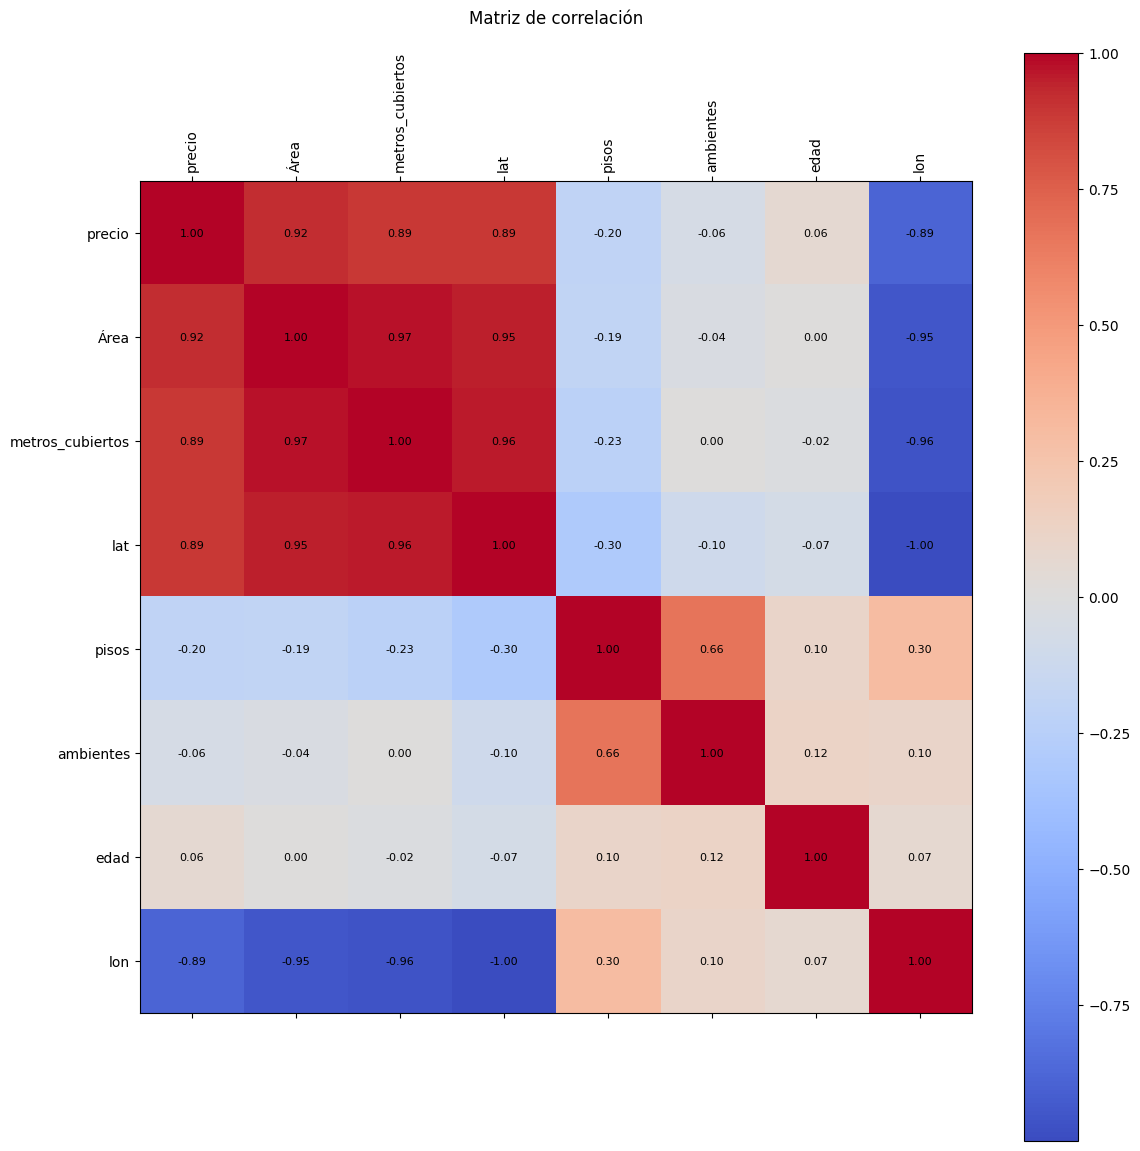

In [296]:
corrmat = df.select_dtypes(include=np.number).corr()

k = len(corrmat.columns)

# ordenar por correlación con precio
cols = corrmat.nlargest(k, 'precio')['precio'].index

# matriz de correlación reordenada
cm = np.corrcoef(df[cols].dropna().values.T)

fig, ax = plt.subplots(figsize=(12, 12))

cax = ax.matshow(cm, cmap='coolwarm')
fig.colorbar(cax)

# ticks
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))

ax.set_xticklabels(cols, rotation=90)
ax.set_yticklabels(cols)

# anotar valores
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{cm[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

plt.title("Matriz de correlación", pad=20)
plt.tight_layout()
plt.show()

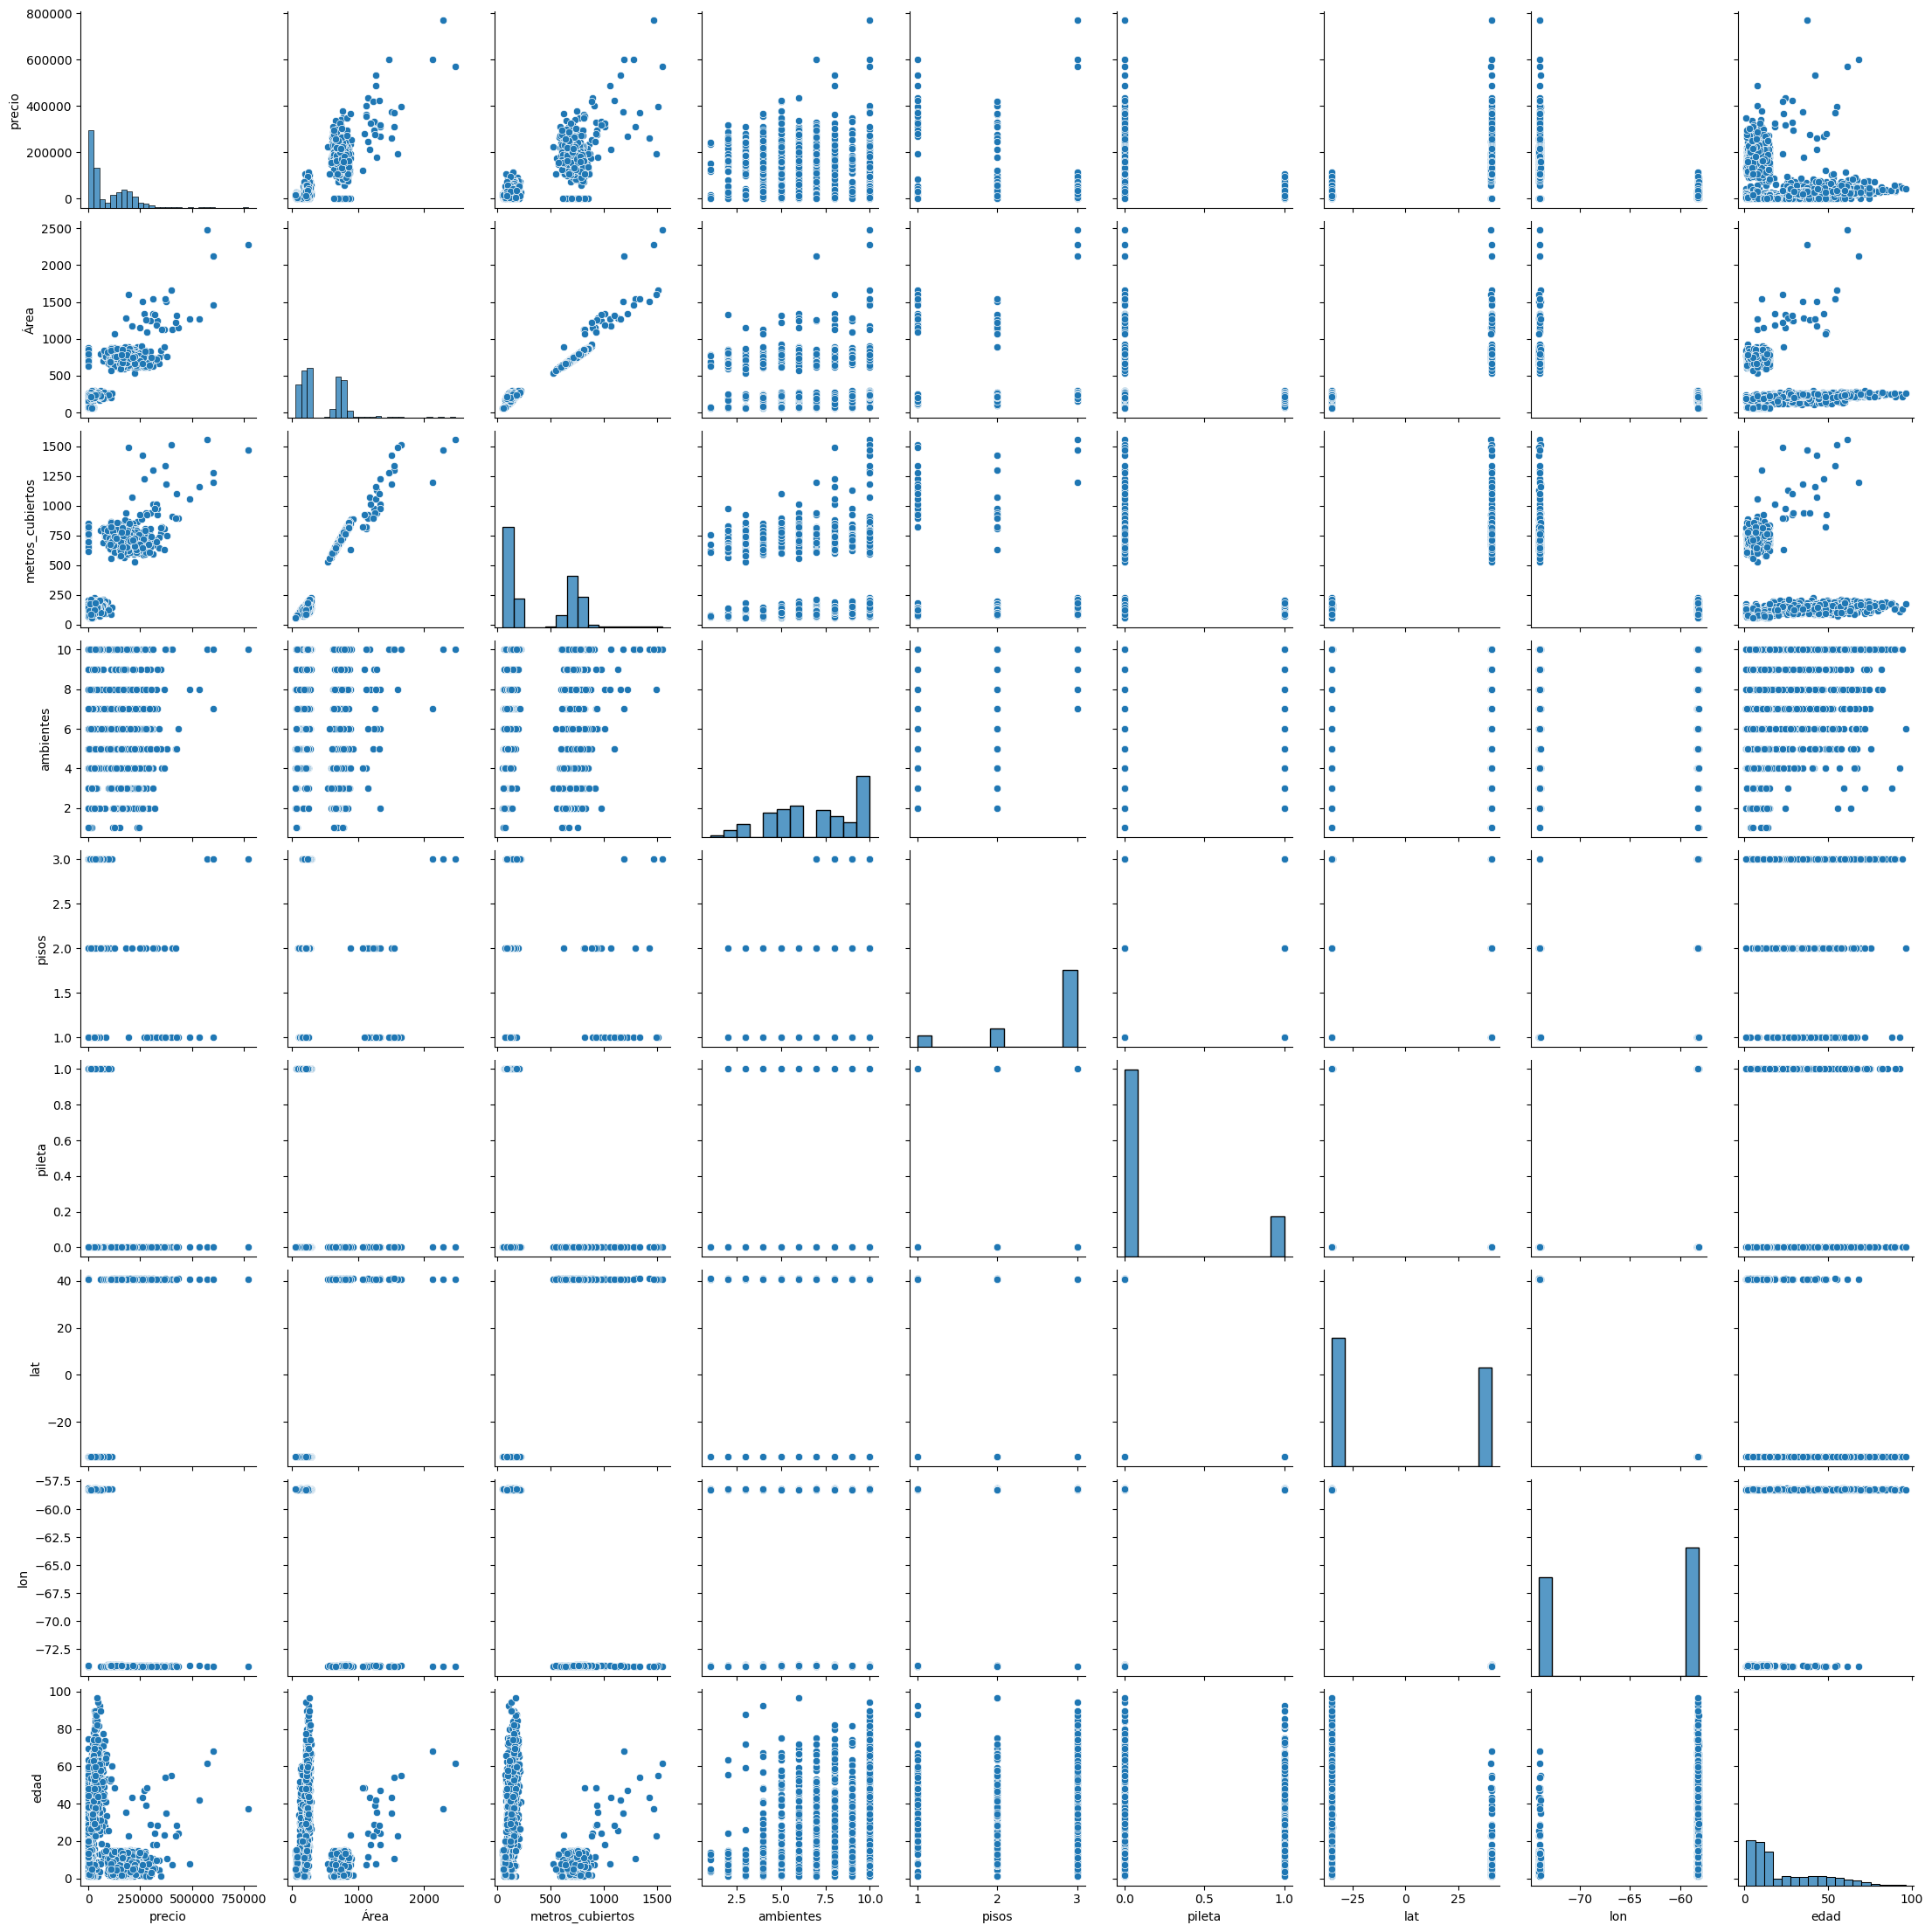

In [297]:
sns.pairplot(df)

EJERCICIO 1: PREPROCESSING

In [298]:
# IMPORTS

from data_splitting import train_val_split
from preprocessing import preprocess
from preprocessing import normalize
from preprocessing import finish_process

In [299]:
# apply preprocessing: drop 0 price, convert ft2 --> m2 and fill 'pisos' with 0
df_processed = preprocess(df)

# split development into training and validation set
train, val = train_val_split(df_processed)

# separate target
y_train = train['precio'].values.copy()
y_val = val['precio'].values.copy()

# drop target column from X_sets
X_train = train.drop(columns=["precio"])
X_val = val.drop(columns=["precio"])

In [300]:
# check train df
train.sample(2)

,precio,tipo,Área,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
471,169.901098,ph,138.999681,115.083253,8,1.0,False,-34.814424,-58.210673,57.563476
60,37009.045098,casa,223.868371,110.260920,10,3.0,False,-34.809540,-58.234251,47.858270


In [301]:
# check sizes
print("Check sets sizes: \n")
print(f'Train: {len(X_train)} samples --> {(len(X_train)/df_processed.shape[0]):.2f}')
print(f'Val: {len(X_val)} samples --> {(len(X_val)/df_processed.shape[0]):.2f}')

Check sets sizes: 

Train: 1190 samples --> 0.80
Val: 298 samples --> 0.20


In [302]:
# finishing processing data --> fill edad, one hot and normalization
X_train_norm, X_val_norm = finish_process(X_train, X_val)

In [303]:
# check final processing
print("Check normalized validation: \n")

columns = X_val_norm.columns

print("Mean\n", X_val_norm[columns].mean())
print()
print("Std\n", X_val_norm[columns].std())

Check normalized validation: 

Mean
 Área               -0.016821
metros_cubiertos    0.003697
ambientes          -0.082080
pisos              -0.109122
pileta             -0.035846
lat                 0.034021
lon                -0.034345
edad               -0.138657
tipo_depto          0.134242
tipo_ph            -0.078826
tipo_otro           0.000000
dtype: float64

Std
 Área                0.954912
metros_cubiertos    0.979871
ambientes           1.028087
pisos               0.994932
pileta              0.969926
lat                 1.005171
lon                 1.005383
edad                0.981357
tipo_depto          0.985777
tipo_ph             0.836553
tipo_otro           0.000000
dtype: float64


EJERCICIO 2: LINEAR REGRESSION IMPLEMENTATION

In [345]:
# IMPORTS

from models import LinearRegression
from metrics import mse, rmse, mae

In [346]:
# checking LinearRegression implementation with model_TEST

# 1 feature: 'metros_cubiertos'
# sets
X_train_mc = X_train_norm[['metros_cubiertos']]
X_val_mc = X_val_norm[['metros_cubiertos']]

# create model
model_TEST_mc = LinearRegression(X_train_mc, y_train)
# train
model_TEST_mc.pseudo_inverse()
error_TEST_mc = model_TEST_mc.gradient_descent()
# predict
y_pred_inv_mc = model_TEST_mc.predict_inv(X_val_mc)
y_pred_grad_mc = model_TEST_mc.predict_grad(X_val_mc)
# print RMSE
print(f"RMSE model_TEST_mc inv: {rmse(y_val, y_pred_inv_mc):.2f}")
print(f"RMSE model_TEST_mc grad: {rmse(y_val, y_pred_grad_mc):.2f}\n")


# 4 features: 'Área', 'metros_cubiertos', 'pileta', 'ambientes'
# sets
X_train_4f = X_train_norm[['Área', 'metros_cubiertos', 'lat', 'ambientes']]
X_val_4f = X_val_norm[['Área', 'metros_cubiertos', 'lat', 'ambientes']]
# create model
model_TEST_4f = LinearRegression(X_train_4f, y_train)
# train
model_TEST_4f.pseudo_inverse()
error_TEST_4f = model_TEST_4f.gradient_descent()
# predict
y_pred_inv_4f = model_TEST_4f.predict_inv(X_val_4f)
y_pred_grad_4f = model_TEST_4f.predict_grad(X_val_4f)
# print RMSE
print(f"RMSE model_TEST_4f inv: {rmse(y_val, y_pred_inv_4f):.2f}")
print(f"RMSE model_TEST_4f grad: {rmse(y_val, y_pred_grad_4f):.2f}")

entra else
RMSE model_TEST_mc inv: 42726.37
RMSE model_TEST_mc grad: 42832.39

entra else
RMSE model_TEST_4f inv: 40964.89
RMSE model_TEST_4f grad: 41956.31


podria imprimir errores...

EJERCICIO 3: REGRESSION MODELS APPLICATION

In [347]:
# M1 MODEL with pseudo inverse
# just using 'Área'

# sets
X_train_M1 = X_train_norm[["Área"]]
X_val_M1 = X_val_norm[["Área"]]
# create model
model_M1 = LinearRegression(X_train_M1, y_train)
# train
model_M1.pseudo_inverse()
# predict
y_pred_M1_train = model_M1.predict_inv(X_train_M1)
y_pred_M1_val = model_M1.predict_inv(X_val_M1)
# print RMSE
print(f"RMSE model_M1 inv train: {rmse(y_train, y_pred_M1_train):.2f}")
print(f"RMSE model_M1 inv val: {rmse(y_val, y_pred_M1_val):.2f}")

entra else
RMSE model_M1 inv train: 43457.87
RMSE model_M1 inv val: 43550.23


In [307]:
model_M1.show_coef_inv()

bias: 97681.65
Área: 88674.30


In [308]:
# M2 MODEL with pseudo inverse
# using 'Área' and 'pileta'

# sets
X_train_M2 = X_train_norm[["Área", "pileta"]]
X_val_M2 = X_val_norm[["Área", "pileta"]]
# create model
model_M2 = LinearRegression(X_train_M2, y_train)
# train
model_M2.pseudo_inverse()
# predict
y_pred_M2_train = model_M2.predict_inv(X_train_M2)
y_pred_M2_val = model_M2.predict_inv(X_val_M2)
# print RMSE
print(f"RMSE model_M2 inv train: {rmse(y_train, y_pred_M2_train):.2f}")
print(f"RMSE model_M2 inv val: {rmse(y_val, y_pred_M2_val):.2f}")

RMSE model_M2 inv train: 43424.13
RMSE model_M2 inv val: 43446.47


In [309]:
# Evaluation 'pileta'

model_M2.show_coef_inv()

bias: 97681.65
Área: 88093.90
pileta: -1808.48


Esto sgnifica: manteniendo area constante, agregar pileta baja el precio en 1808 dolares.

POR CHAT
El coeficiente asociado a la variable “pileta” resulta negativo, lo que indicaría que, manteniendo constante el área, la presencia de una pileta disminuiría el valor de la propiedad en aproximadamente 1800 dólares.

Sin embargo, este resultado puede deberse a la falta de variables relevantes en el modelo, como la ubicación o el tipo de propiedad, lo que podría generar una estimación sesgada del efecto de la pileta. Por lo tanto, no se puede concluir de manera definitiva que construir una pileta reduzca el valor de la propiedad

In [310]:
# M3 MODEL with pseudo inverse
# using 'Área', 'metros_cubiertos' ,'ambientes', 'pileta', 'lat', 'edad'

# sets
X_train_M3 = X_train_norm[["Área", "metros_cubiertos" , "ambientes", "pileta", "lat", "edad"]]
X_val_M3 = X_val_norm[["Área", "metros_cubiertos" , "ambientes", "pileta", "lat", "edad"]]
# create model
model_M3 = LinearRegression(X_train_M3, y_train)
# train
model_M3.pseudo_inverse()
# predict
y_pred_M3_train = model_M3.predict_inv(X_train_M3)
y_pred_M3_val = model_M3.predict_inv(X_val_M3)
# print RMSE
print(f"RMSE model_M3 inv train: {rmse(y_train, y_pred_M3_train):.2f}")
print(f"RMSE model_M3 inv val: {rmse(y_val, y_pred_M3_val):.2f}")

RMSE model_M3 inv train: 41270.55
RMSE model_M3 inv val: 40925.69


In [311]:
# M3 using grad!!
# train
err_M3 = model_M3.gradient_descent()
# predict
y_pred_M3_grad_train = model_M3.predict_grad(X_train_M3)
y_pred_M3_grad_val = model_M3.predict_grad(X_val_M3)
# print RMSE
print(f"RMSE model_M3 grad train: {rmse(y_train, y_pred_M3_grad_train):.2f}")
print(f"RMSE model_M3 grad val: {rmse(y_val, y_pred_M3_grad_val):.2f}")

RMSE model_M3 grad train: 46148.95
RMSE model_M3 grad val: 41785.97


EJERCICIO 4: FEATURE ENGINEERING

In [312]:
# IMPORTS

from preprocessing import fill_edad_median, one_hot_encoder
from utils import feature_engineering, add_high_degree_features

In [313]:
# Add some interesting feature combinations

# using X_train and X_val coming from train_val_split()
# first fill data and encode
X_train_proc, X_val_proc = fill_edad_median(X_train, X_val)
X_train_proc, X_val_proc = one_hot_encoder(X_train_proc, X_val_proc)

In [314]:
# Feature Engineering M4

# apply feature engineering for M4
train_fe = feature_engineering(X_train_proc)
val_fe = feature_engineering(X_val_proc)
# normalize
X_train_fe_norm, X_val_fe_norm = normalize(train_fe, val_fe)

In [315]:
# MODEL M4 
# using M3 features and new features

# features M4
features_M4 = ["Área", "metros_cubiertos" ,"ambientes","pileta","lat","edad", "area_log", "area_sq", "densidad",
    "area_pileta", "ambientes_por_area"]
# sets
X_train_M4 = X_train_fe_norm[features_M4]
X_val_M4 = X_val_fe_norm[features_M4]
# create model
model_M4 = LinearRegression(X_train_M4, y_train)
# train
model_M4.pseudo_inverse()
# predict
y_pred_M4_inv_train = model_M4.predict_inv(X_train_M4)
y_pred_M4_inv_val = model_M4.predict_inv(X_val_M4)
# print RMSE
print(f"RMSE model_M4 inv train: {rmse(y_train, y_pred_M4_inv_train):.2f}")
print(f"RMSE model_M4 inv val: {rmse(y_val, y_pred_M4_inv_val):.2f}")

RMSE model_M4 inv train: 39969.74
RMSE model_M4 inv val: 39583.50


In [316]:
# M4 using grad!!
# train
err_M4 = model_M4.gradient_descent()
# predict
y_pred_M4_grad_train = model_M4.predict_grad(X_train_M4)
y_pred_M4_grad_val = model_M4.predict_grad(X_val_M4)
# print RMSE
print(f"RMSE model_M4 grad train: {rmse(y_train, y_pred_M4_grad_train):.2f}")
print(f"RMSE model_M4 grad val: {rmse(y_val, y_pred_M4_grad_val):.2f}")

RMSE model_M4 grad train: 44980.31
RMSE model_M4 grad val: 42524.93


In [317]:
# Feature Engineering M5

features_M5 = ["Área", "metros_cubiertos" ,"ambientes", "pileta", "lat", "edad"]
# apply feature engineering for M5
X_train_M5 = add_high_degree_features(X_train_proc, cols=features_M5)
X_val_M5 = add_high_degree_features(X_val_proc, cols=features_M5)
# normalize
X_train_M5_norm, X_val_M5_norm = normalize(X_train_M5, X_val_M5)

In [318]:
# MODEL M5
# using 50 features with high degree each

# create model
model_M5 = LinearRegression(X_train_M5_norm, y_train)
# train
model_M5.pseudo_inverse()
# predict
y_pred_M5_inv_train = model_M5.predict_inv(X_train_M5_norm)
y_pred_M5_inv_val = model_M5.predict_inv(X_val_M5_norm)
# print RMSE
print(f"RMSE model_M5 inv train: {rmse(y_train, y_pred_M5_inv_train):.2f}")
print(f"RMSE model_M5 inv val: {rmse(y_val, y_pred_M5_inv_val):.2f}")

RMSE model_M5 inv train: 30661.10
RMSE model_M5 inv val: 33083.67


In [319]:
# M5 using grad!!
# train
err_M5 = model_M5.gradient_descent(lr=0.001)
# predict
y_pred_M5_grad_train = model_M5.predict_grad(X_train_M5_norm)
y_pred_M5_grad_val = model_M5.predict_grad(X_val_M5_norm)
# print RMSE
print(f"RMSE model_M5 grad train: {rmse(y_train, y_pred_M5_grad_train):.2f}")
print(f"RMSE model_M5 grad val: {rmse(y_val, y_pred_M5_grad_val):.2f}")

RMSE model_M5 grad train: 43525.16
RMSE model_M5 grad val: 40937.75


In [320]:
# LERNING RATE MUUUUUCH SMALLER
# Undersatanding why we dont see overfitting in gradient_descent
# train
err_M5 = model_M5.gradient_descent(lr=0.000001)
# predict
y_pred_M5_grad_train = model_M5.predict_grad(X_train_M5_norm)
y_pred_M5_grad_val = model_M5.predict_grad(X_val_M5_norm)
# print RMSE
print(f"RMSE model_M5 grad train: {rmse(y_train, y_pred_M5_grad_train):.2f}")
print(f"RMSE model_M5 grad val: {rmse(y_val, y_pred_M5_grad_val):.2f}")

RMSE model_M5 grad train: 136779.23
RMSE model_M5 grad val: 126380.50


Al aumentar significativamente la cantidad de características mediante transformaciones polinómicas de alto grado, el modelo M5 logra reducir considerablemente el error en el conjunto de entrenamiento. Sin embargo, este comportamiento no se replica en el conjunto de validación, donde el error aumenta, evidenciando un claro caso de sobreajuste (overfitting).

Además, el método de descenso por gradiente presenta problemas de estabilidad numérica, debido a los grandes valores generados por las transformaciones polinómicas, lo que provoca divergencia en el entrenamiento.

Al reducir excesivamente el learning rate, el descenso por gradiente no logra converger hacia una solución óptima, quedando estancado en valores de error elevados. Esto evidencia la sensibilidad del algoritmo a la elección del learning rate, especialmente en presencia de variables con magnitudes muy grandes como las generadas en el modelo M5.

EJERCICIO 5: REGULARIZATION

In [321]:
# IMPORTS

from data_splitting import cross_val

In [322]:
# RIDGE REGRESSION L2

# Define lambdas (log scale)
lambdas_L2 = np.logspace(-3, 3, 20)

# Save coefs
coefs_L2 = []

for l in lambdas_L2:
    model_L2 = LinearRegression(X_train_M4, y_train, l2=l, l1=0)
    model_L2.pseudo_inverse()
    
    coefs_L2.append(model_L2.coef_inv.flatten())

coefs_L2 = np.array(coefs_L2)

In [323]:
print("Shape coeficientes:", coefs_L2.shape)
print(f"# lambdas: {coefs_L2.shape[0]}")
print(f"# features: {coefs_L2.shape[1]}")

Shape coeficientes: (20, 12)
# lambdas: 20
# features: 12


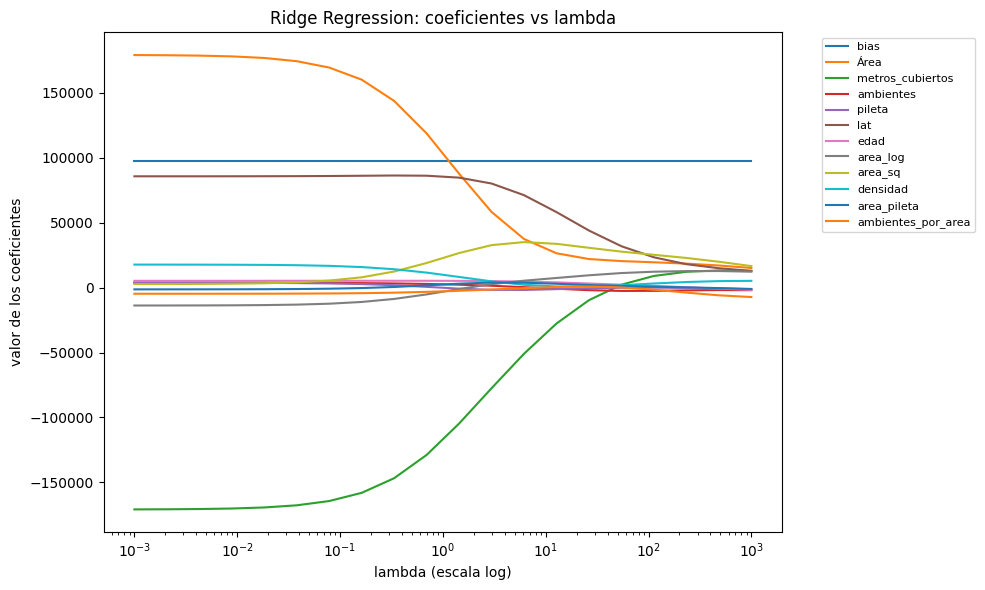

In [324]:
# Graph
plt.figure(figsize=(10,6))

for i in range(coefs_L2.shape[1]):
    plt.plot(lambdas_L2, coefs_L2[:, i], label=model_L2.feature_names[i])

plt.xscale("log")
plt.xlabel("lambda (escala log)")
plt.ylabel("valor de los coeficientes")
plt.title("Ridge Regression: coeficientes vs lambda")

# opcional: si hay muchas features puede saturar
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)

plt.tight_layout()
plt.show()

A medida que aumenta el coeficiente de regularización λ, se observa que todos los coeficientes del modelo tienden a disminuir en magnitud, acercándose progresivamente a cero. Esto evidencia el efecto de la regularización L2, que penaliza los valores grandes de los parámetros para reducir la complejidad del modelo.

Se destaca que el término independiente (bias) permanece constante, lo cual es consistente con la implementación donde no se aplica regularización sobre este parámetro.

Asimismo, algunas variables como el área y la ubicación (latitud) mantienen valores relativamente altos incluso para valores grandes de λ, lo que sugiere que son características más relevantes para la predicción del precio. En contraste, otras variables tienden rápidamente a cero, indicando menor importancia en el modelo.

In [325]:
# LASSO REGRESSION L1

# Define lambdas (log scale)
lambdas_L1 = np.logspace(-3, 5, 30)

# save coefs
coefs_L1 = []

for l in lambdas_L1:
    model_L1 = LinearRegression(X_train_M4, y_train, l2=0, l1=l)

    model_L1.gradient_descent()
    
    coefs_L1.append(model_L1.coef_grad.flatten())

coefs_L1 = np.array(coefs_L1)

In [326]:
print("Shape coefs L1:", coefs_L1.shape)
print(f"# lambdas: {coefs_L1.shape[0]}")
print(f"# features: {coefs_L1.shape[1]}")

Shape coefs L1: (30, 12)
# lambdas: 30
# features: 12


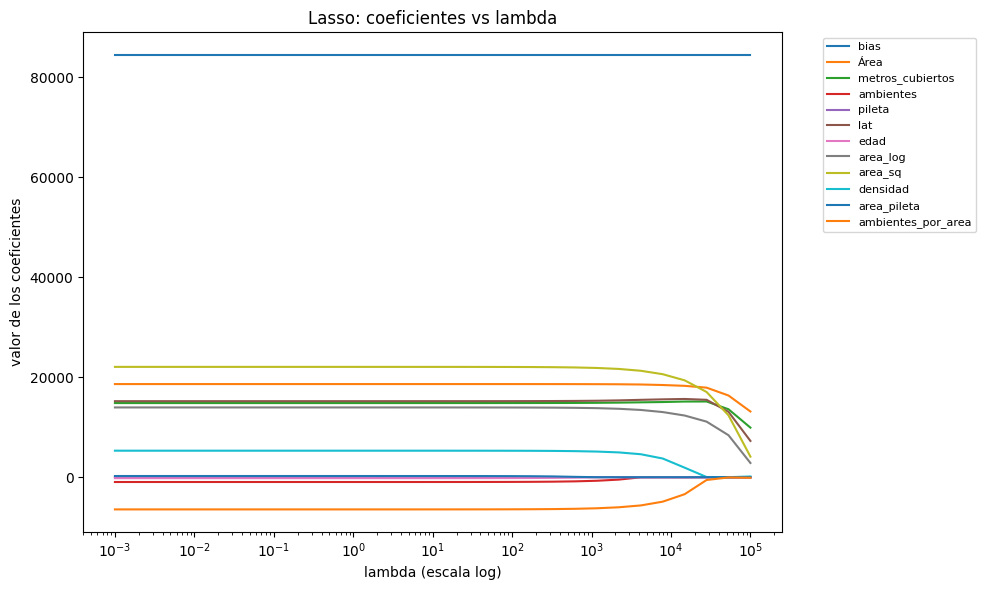

In [327]:
# Graph
plt.figure(figsize=(10,6))

for i in range(coefs_L1.shape[1]):
    plt.plot(lambdas_L1, coefs_L1[:, i], label=model_L1.feature_names[i])

plt.xscale("log")
plt.xlabel("lambda (escala log)")
plt.ylabel("valor de los coeficientes")
plt.title("Lasso: coeficientes vs lambda")

# opcional: si hay muchas features puede saturar
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)

plt.tight_layout()
plt.show()

CONCLUSION REGRESION: 

In [328]:
# CROSS VALIDATION!

# df_processed: development set preprocessed
# caclulate Cross Calidation in order to find optimal lambda for each regression
best_l2, errors_l2 = cross_val(df_processed, lambdas_L2, "ridge")
best_l1, errors_l1 = cross_val(df_processed, lambdas_L1, "lasso")

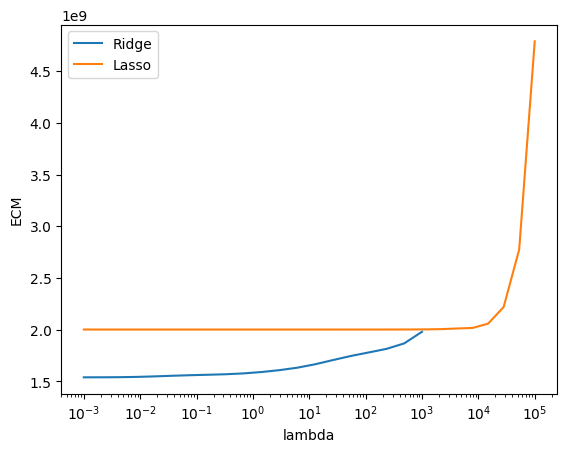

In [329]:
# Graph EMC vs Lambda
plt.plot(lambdas_L2, list(errors_l2.values()), label="Ridge")
plt.plot(lambdas_L1, list(errors_l1.values()), label="Lasso")

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("ECM")
plt.legend()
plt.show()

In [330]:
# Optimal lambda for each regression
print("Optimal Lambdas")
print(f"Lasso: {best_l1}")
print(f"Ridge: {best_l2}")

Optimal Lambdas
Lasso: 0.001
Ridge: 0.001


In [331]:
# Which regression has less error?
print("Lasso: ", np.sqrt(errors_l1[best_l1]))
print("Ridge: ", np.sqrt(errors_l2[best_l2]))

Lasso:  44735.0385238173
Ridge:  39231.22450568082


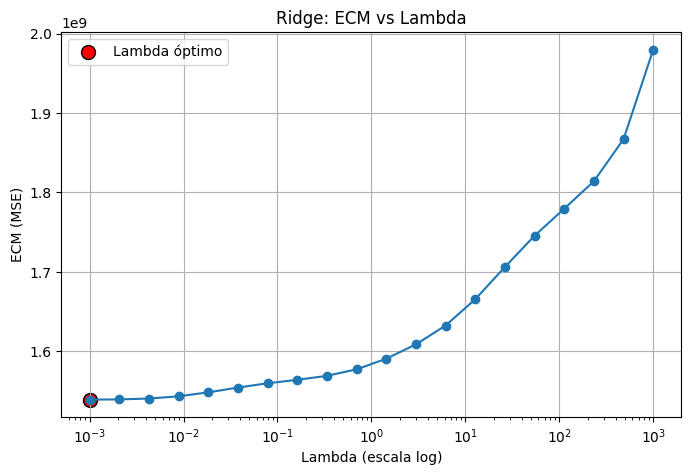

In [332]:
plt.figure(figsize=(8,5))

plt.plot(errors_l2.keys(), errors_l2.values(), marker='o')

plt.scatter(best_l2, errors_l2[best_l2], s=100, label="Lambda óptimo", c='red', edgecolors='black')

plt.xscale("log")
plt.xlabel("Lambda (escala log)")
plt.ylabel("ECM (MSE)")
plt.title("Ridge: ECM vs Lambda")

plt.legend()
plt.grid()
plt.show()

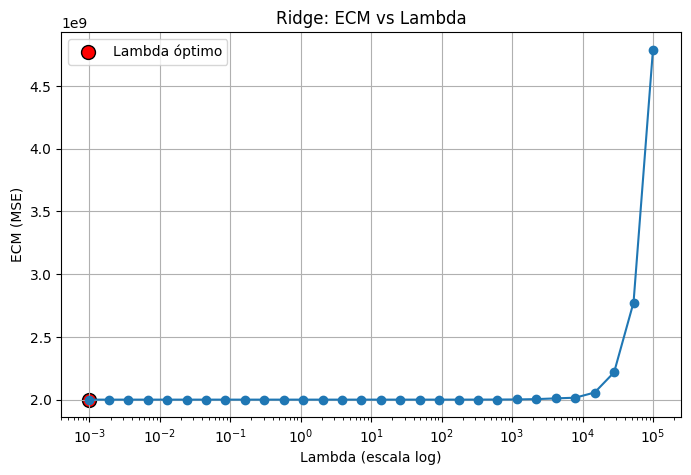

In [333]:
plt.figure(figsize=(8,5))

plt.plot(errors_l1.keys(), errors_l1.values(), marker='o')

plt.scatter(best_l1, errors_l1[best_l1], s=100, label="Lambda óptimo", c='red', edgecolors='black')

plt.xscale("log")
plt.xlabel("Lambda (escala log)")
plt.ylabel("ECM (MSE)")
plt.title("Ridge: ECM vs Lambda")

plt.legend()
plt.grid()
plt.show()

In [348]:
# Model M6 with optimal lambda and X_train from M4

# create model
model_M6 = LinearRegression(X_train_M4, y_train, l2=best_l2, l1=0)
# train
model_M6.pseudo_inverse()
# predict
y_pred_M6_train = model_M6.predict_inv(X_train_M4)
y_pred_M6_val = model_M6.predict_inv(X_val_M4)
# print RMSE
print(f"RMSE model_M6 train: {rmse(y_train, y_pred_M6_train):.2f}")
print(f"RMSE model_M6 val: {rmse(y_val, y_pred_M6_val):.2f}")

entra else
RMSE model_M6 train: 39969.74
RMSE model_M6 val: 39582.64


NO MEJORA CASI NADA CON LA REGULARIZACION???
RMSE model_M4 inv train: 39969.74
RMSE model_M4 inv val: 39583.50

EJERCICIO 6: MODEL SELECTION AND EVALUATION

In [371]:
# IMPORTS

from utils import learning_curve_model

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


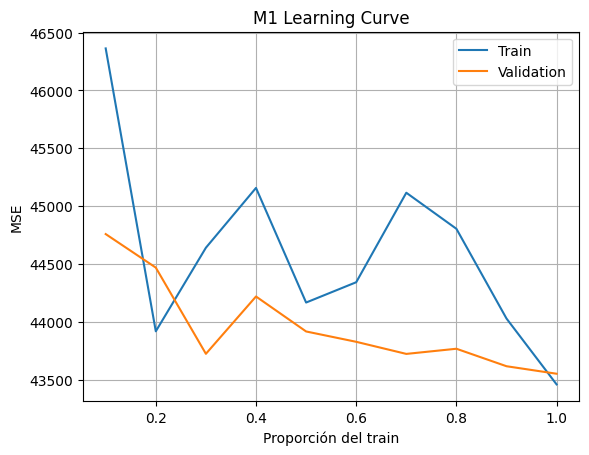

In [354]:
sizes, train_err, val_err = learning_curve_model(train, val, "M1")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M1 Learning Curve")
plt.legend()
plt.grid()
plt.show()

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


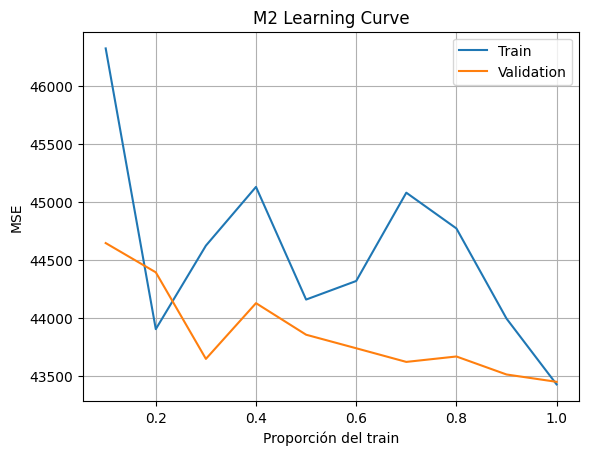

In [355]:
sizes, train_err, val_err = learning_curve_model(train, val, "M2")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M2 Learning Curve")
plt.legend()
plt.grid()
plt.show()

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


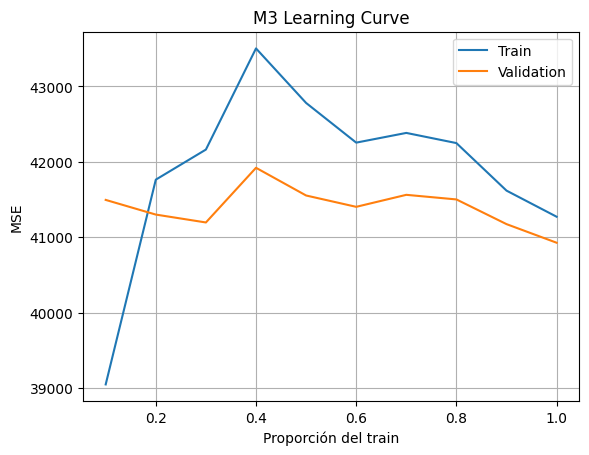

In [356]:
sizes, train_err, val_err = learning_curve_model(train, val, "M3")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M3 Learning Curve")
plt.legend()
plt.grid()
plt.show()

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


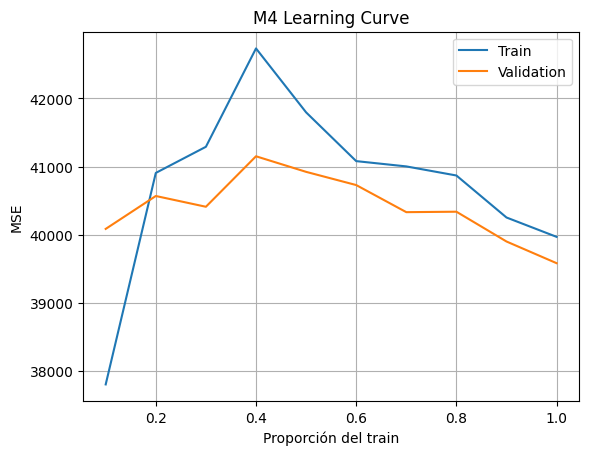

In [357]:
sizes, train_err, val_err = learning_curve_model(train, val, "M4")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M4 Learning Curve")
plt.legend()
plt.grid()
plt.show()

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


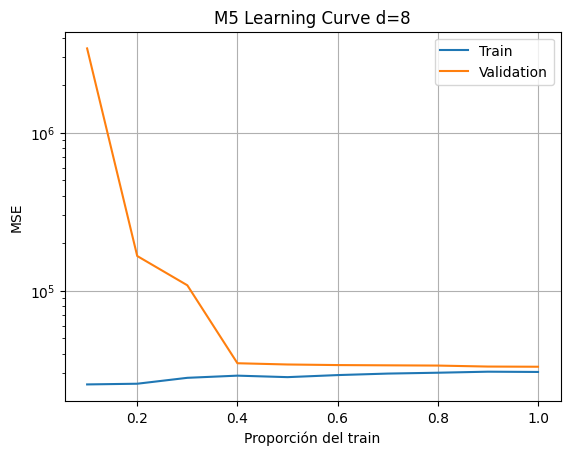

In [372]:
sizes, train_err, val_err = learning_curve_model(train, val, "M5")

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.yscale('log')

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M5 Learning Curve - log scale")
plt.legend()
plt.grid()
plt.show()

entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else
entra else


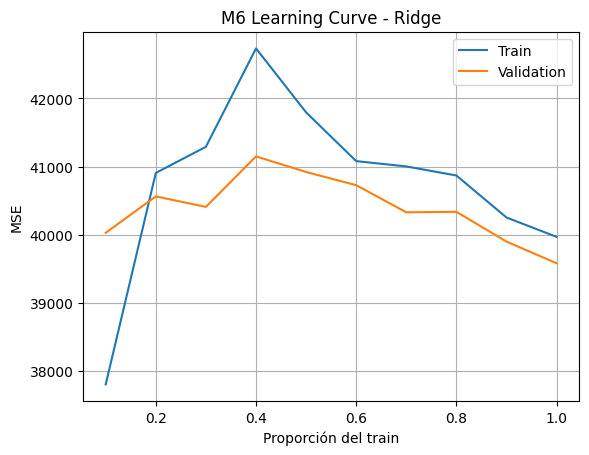

In [359]:
sizes, train_err, val_err = learning_curve_model(train, val, "M6", best_l2=best_l2)

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M6 Learning Curve - Ridge")
plt.legend()
plt.grid()
plt.show()

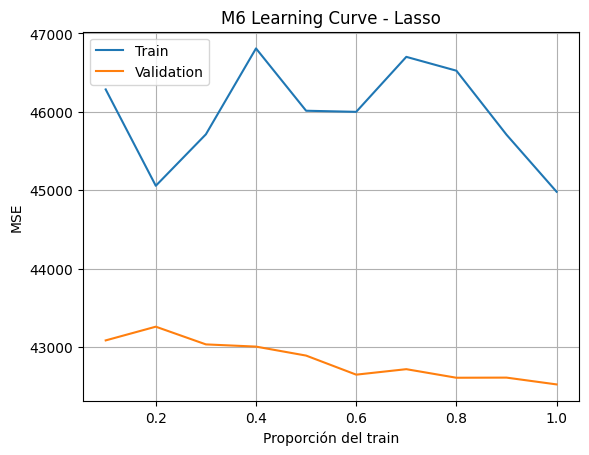

In [360]:
sizes, train_err, val_err = learning_curve_model(train, val, "M6", best_l1=best_l1)

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")

plt.xlabel("Proporción del train")
plt.ylabel("MSE")
plt.title("M6 Learning Curve - Lasso")
plt.legend()
plt.grid()
plt.show()

EVALUAMOS CAPACIDAD PREDICTIVA

ELIJO MODELO M6 CON RIDGE


FINAL TRAINING

In [ ]:
# SEPARO TRAIN Y TEST

In [373]:
df_test = pd.read_csv("../data/raw/casas_test.csv")
df_test_processed = preprocess(df_test)

# YA TENIAMOS DF_PROCESSED QUE ES TODO EL TRAIN COMPLETO



In [375]:
y_full_train = df_processed['precio'].values.copy()
y_test = df_test_processed['precio'].values.copy()

X_full_train = df_processed.drop(columns=['precio'])
X_test = df_test_processed.drop(columns=['precio'])

In [376]:
# fill, one hot, feature engineering, normalize

X_full_train, X_test = fill_edad_median(X_full_train, X_test)
X_full_train, X_test = one_hot_encoder(X_full_train, X_test)

X_full_train_fe = feature_engineering(X_full_train)
X_test_fe = feature_engineering(X_test)

features_final = ["Área", "metros_cubiertos" ,"ambientes","pileta","lat","edad", "area_log", "area_sq", "densidad",
    "area_pileta", "ambientes_por_area"]

X_full_train = X_full_train_fe[features_final]
X_test = X_test_fe[features_final]

X_full_train_norm, X_test_norm = normalize(X_full_train, X_test)

In [380]:
# create
model_FINAL = LinearRegression(X_full_train_norm, y_full_train, l2=best_l2, l1=0)
# train
model_FINAL.pseudo_inverse()
# predict
y_pred_FINAL_train = model_FINAL.predict_inv(X_full_train_norm)
y_pred_FINAL_test = model_FINAL.predict_inv(X_test_norm)
# print res

print("EVALUACION FINAL EN TEST M6\n")
print(f"RMSE model_FINAL test: {rmse(y_test, y_pred_FINAL_test):.2f}")
print(f"MAE model_FINAL test: {mae(y_test, y_pred_FINAL_test):.2f}")

entra else
EVALUACION FINAL EN TEST M6

RMSE model_FINAL test: 36462.85
MAE model_FINAL test: 23807.62
